In [2]:
import torch
print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())
import torchaudio
import numpy as np
print(torchaudio.__version__)
import matplotlib.pyplot as plt

2.6.0+cu124
CUDA available: True
2.6.0+cu124


In [3]:
def sin_wav(freq, Fs, duration):
    t = torch.linspace(0,duration,int(Fs*duration))
    return torch.sin(t*2*np.pi*freq)

def make_phase(freq, Fs, duration):
    # returns the phase ramp tensor before sin is applied
    t = torch.linspace(0, duration, int(Fs*duration))
    return t * (2*np.pi) * freq
def apply_phase_mod(phase, modulation):
    # adds modulation to phase and applies sin, returns audio signal
    modulated_phase = phase+modulation
    return torch.sin(modulated_phase)

In [4]:
def operator(freq, Fs, duration, level, modulation=None):
    # returns operator output tensor [n_samples]
    self_phase = make_phase(freq, Fs, duration)
    if modulation is None:
        modulation = torch.zeros_like(self_phase)
    return apply_phase_mod(self_phase,modulation) * level
    
    

In [5]:
# Smoke tests
Fs = 44100
numsec = 1
t = torch.linspace(0,1,Fs*numsec)
a = torch.sin(t*2*np.pi*440)
b = sin_wav(440, Fs, numsec)
print("Shape: ", a.shape)
print("Shape: ", b.shape)

phase = make_phase(440, Fs, numsec)
silence = torch.zeros_like(phase)
output = apply_phase_mod(phase, silence)
print("PhaseMod with silence == original: ", torch.equal(output, b))
op_out = operator(440, Fs, numsec, 1.0)
print("Operator matches sin wav: ", torch.equal(op_out, b))
op_half = operator(440, Fs, numsec, 0.5)
print("Half amp max: ", op_half.abs().max().item())


Shape:  torch.Size([44100])
Shape:  torch.Size([44100])
PhaseMod with silence == original:  True
Operator matches sin wav:  True
Half amp max:  0.5


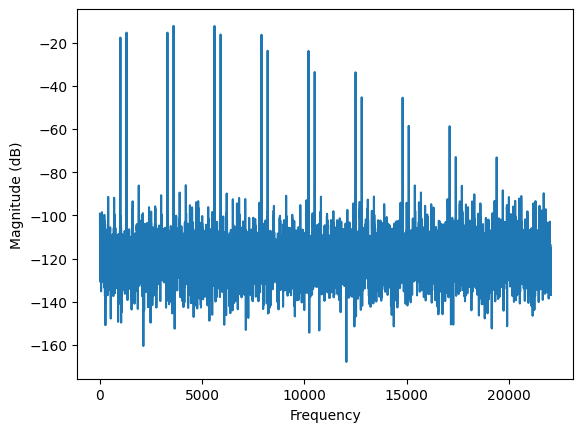

In [8]:
# Multiple Operator tests
Fs = 44100
numsec = 1.0
freq = 1000
op0_ratio = 2.3
op0_level = 3
op1_ratio = 1.0
op1_level = 1.0

op0_out = operator(freq*op0_ratio, Fs, numsec, op0_level)
op1_out = operator(freq*op1_ratio, Fs, numsec, op1_level, op0_out)

plt.magnitude_spectrum(op1_out.numpy(), Fs=Fs, scale='dB')
plt.show()
